# 03 · LightGBM Training

Loads processed artefacts, joins tabular + graph features, runs 5-fold stratified CV
to find best_iteration, retrains on full data, computes SHAP values, and saves the model.

**Prerequisite:** run notebook `02` first (or the pipeline `features` + `graph` stages).

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import gc, json, pickle, time

import numpy as np
import lightgbm as lgb
import shap
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor":"#0F1117","axes.facecolor":"#1A1D27","axes.edgecolor":"#2E3347",
    "text.color":"#E0E0E0","axes.labelcolor":"#E0E0E0","xtick.color":"#9AA0B0",
    "ytick.color":"#9AA0B0","grid.color":"#2E3347","grid.linestyle":"--",
    "font.family":"monospace","figure.dpi":120,
})
PAL = {"normal":"#4A90D9","fraud":"#E84545","accent":"#F5A623","purple":"#A259FF"}
print("Imports OK")


Imports OK


In [2]:
from pathlib import Path
# ── Change this to point to your repo root if running from elsewhere
REPO_ROOT = Path(".").resolve().parent  # assumes notebook is in notebooks/
DATA_DIR  = REPO_ROOT / "data" / "raw"
PROC_DIR  = REPO_ROOT / "data" / "processed"
MODEL_DIR = REPO_ROOT / "models"
OUT_DIR   = REPO_ROOT / "outputs"
for d in [PROC_DIR, MODEL_DIR, OUT_DIR]: d.mkdir(parents=True, exist_ok=True)
print(f"Data  : {DATA_DIR}")
print(f"Proc  : {PROC_DIR}")

Data  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/raw
Proc  : /Users/MYOUSSF/Desktop/Projects/fraud_detection_project/data/processed


In [3]:
# ── Load artefacts ────────────────────────────────────────────────────────────
with open(PROC_DIR/"feature_meta.json") as fh: feat_meta = json.load(fh)
with open(PROC_DIR/"graph_meta.json")   as fh: graph_meta = json.load(fh)

tab_feats   = feat_meta["features"]
gph_feats   = graph_meta["graph_features"]
feature_names = tab_feats + gph_feats
N_TAB = len(tab_feats)
print(f"Features: {len(tab_feats)} tabular + {len(gph_feats)} graph = {len(feature_names)} total")


Features: 32 tabular + 7 graph = 39 total


In [4]:
# ── Join tabular + graph ──────────────────────────────────────────────────────
def join_features(G, g_tx, X_tab, tx_ids):
    lookup = {int(tid): i for i, tid in enumerate(tx_ids)}
    block  = np.zeros((len(G), N_TAB), dtype=np.float32)
    for i, tid in enumerate(g_tx):
        idx = lookup.get(int(tid))
        if idx is not None: block[i] = X_tab[idx]
    return np.hstack([block, G])

X_train_tab   = np.load(PROC_DIR/"X_train_tab_all.npy")
tx_ids_train  = np.load(PROC_DIR/"tx_ids_train_all.npy")
G_train       = np.load(PROC_DIR/"graph_features_train.npy")
g_tx_train    = np.load(PROC_DIR/"graph_tx_ids_train.npy")
y_train       = np.load(PROC_DIR/"y_graph_train.npy")

X_test_tab    = np.load(PROC_DIR/"X_test_tab.npy")
tx_ids_test   = np.load(PROC_DIR/"tx_ids_test_tab.npy")
G_test        = np.load(PROC_DIR/"graph_features_test.npy")
g_tx_test     = np.load(PROC_DIR/"graph_tx_ids_test.npy")
y_test        = np.load(PROC_DIR/"y_graph_test.npy")

X_train = join_features(G_train, g_tx_train, X_train_tab, tx_ids_train)
X_test  = join_features(G_test,  g_tx_test,  X_test_tab,  tx_ids_test)
del G_train, G_test, X_train_tab, X_test_tab; gc.collect()

print(f"X_train: {X_train.shape}  fraud={y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"X_test : {X_test.shape}   fraud={y_test.sum():,} ({y_test.mean()*100:.2f}%)")


X_train: (472432, 39)  fraud=16,530 (3.50%)
X_test : (118108, 39)   fraud=4,133 (3.50%)


## 1 · Model parameters

In [5]:
# ── Edit these freely ─────────────────────────────────────────────────────────
N_ESTIMATORS          = 2000
LEARNING_RATE         = 0.03
NUM_LEAVES            = 63
MIN_CHILD_SAMPLES     = 20
SUBSAMPLE             = 0.8
COLSAMPLE_BYTREE      = 0.8
REG_ALPHA             = 0.1
REG_LAMBDA            = 1.0
EARLY_STOPPING_ROUNDS = 100
CV_FOLDS              = 5
RANDOM_STATE          = 42
N_SHAP_SAMPLES        = 2000

n_normal = int((y_train == 0).sum())
n_fraud  = int((y_train == 1).sum())
SPW      = n_normal / max(n_fraud, 1)

PARAMS = dict(
    objective="binary", metric="average_precision", boosting_type="gbdt",
    n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE,
    num_leaves=NUM_LEAVES, min_child_samples=MIN_CHILD_SAMPLES,
    subsample=SUBSAMPLE, subsample_freq=1, colsample_bytree=COLSAMPLE_BYTREE,
    reg_alpha=REG_ALPHA, reg_lambda=REG_LAMBDA, scale_pos_weight=SPW,
    random_state=RANDOM_STATE, device="cpu", verbose=-1,
)
print(f"scale_pos_weight = {SPW:.1f}  (normal={n_normal:,}  fraud={n_fraud:,})")


scale_pos_weight = 27.6  (normal=455,902  fraud=16,530)


## 2 · Cross-validation

In [6]:
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
oof        = np.zeros(len(X_train))
cv_aurocs  = []
best_iters = []

print(f"{'Fold':>5} {'AUROC':>8} {'Best iter':>10} {'Time':>8}")
print("-" * 36)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    t0  = time.time()
    clf = lgb.LGBMClassifier(**PARAMS, n_jobs=-1)
    clf.fit(
        X_train[tr_idx], y_train[tr_idx],
        eval_set=[(X_train[val_idx], y_train[val_idx])],
        feature_name=feature_names,
        callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )
    val_proba    = clf.predict_proba(X_train[val_idx])[:, 1]
    oof[val_idx] = val_proba
    fold_auroc   = roc_auc_score(y_train[val_idx], val_proba)
    cv_aurocs.append(fold_auroc)
    best_iters.append(clf.best_iteration_)
    print(f"{fold+1:>5} {fold_auroc:>8.4f} {clf.best_iteration_:>10} {time.time()-t0:>7.1f}s")

cv_mean = float(np.mean(cv_aurocs)); cv_std = float(np.std(cv_aurocs))
print(f"\nCV mean={cv_mean:.4f} +/- {cv_std:.4f}  |  OOF AUROC={roc_auc_score(y_train, oof):.4f}")


 Fold    AUROC  Best iter     Time
------------------------------------
    1   0.8817       1996    34.1s
    2   0.8770       1999    32.4s
    3   0.8826       2000    33.1s
    4   0.8754       2000    33.5s
    5   0.8833       1999    33.7s

CV mean=0.8800 +/- 0.0032  |  OOF AUROC=0.8800


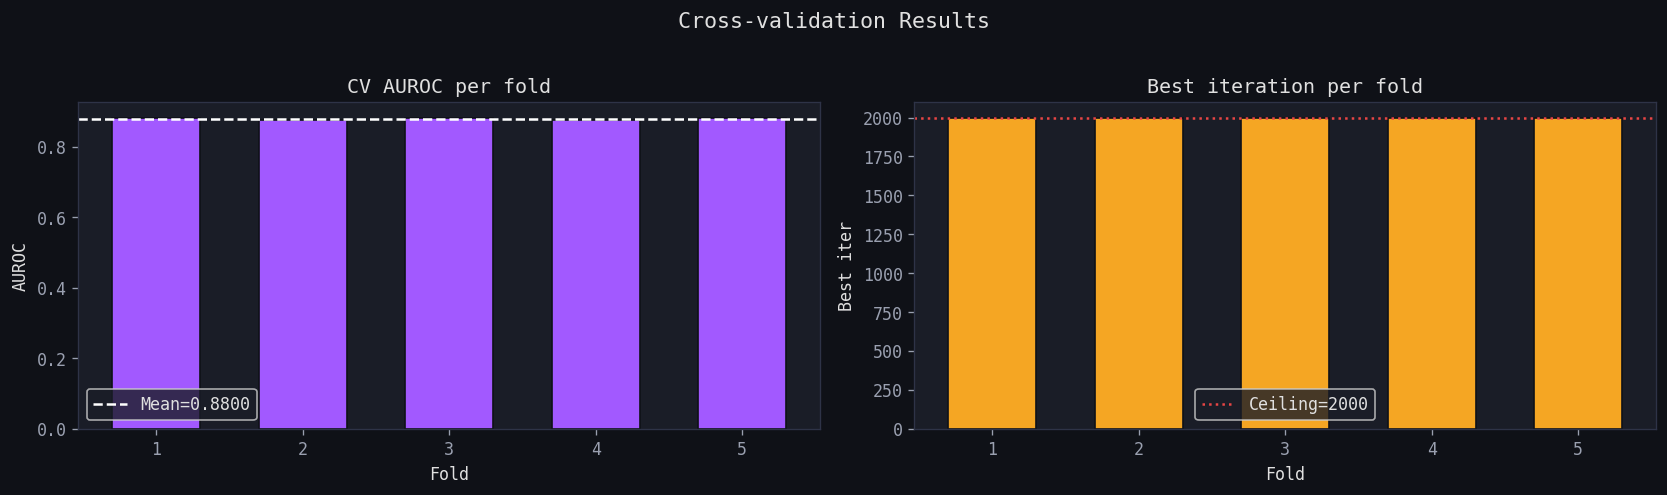


Median best_iteration = 1999  →  will train final model with n_estimators=1999
⚠  best_iter near ceiling — consider raising n_estimators in PARAMS


In [7]:
# ── CV fold AUROC chart ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.patch.set_facecolor("#0F1117")

axes[0].bar(range(1, CV_FOLDS+1), cv_aurocs, color=PAL["purple"], edgecolor="#0F1117", width=0.6)
axes[0].axhline(cv_mean, color="white", ls="--", lw=1.5, label=f"Mean={cv_mean:.4f}")
axes[0].set_title("CV AUROC per fold", color="#E0E0E0")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("AUROC"); axes[0].legend()

axes[1].bar(range(1, CV_FOLDS+1), best_iters, color=PAL["accent"], edgecolor="#0F1117", width=0.6)
axes[1].axhline(N_ESTIMATORS, color=PAL["fraud"], ls=":", lw=1.5, label=f"Ceiling={N_ESTIMATORS}")
axes[1].set_title("Best iteration per fold", color="#E0E0E0")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Best iter"); axes[1].legend()

plt.suptitle("Cross-validation Results", fontsize=13, color="#E0E0E0", y=1.02)
plt.tight_layout(); plt.show()

best_n = int(np.median(best_iters))
print(f"\nMedian best_iteration = {best_n}  →  will train final model with n_estimators={best_n}")
if best_n >= N_ESTIMATORS - 50:
    print("⚠  best_iter near ceiling — consider raising n_estimators in PARAMS")


## 3 · Final model training

In [8]:
print(f"Training final LightGBM | n_estimators={best_n} ...")
t0    = time.time()
model = lgb.LGBMClassifier(**{**PARAMS, "n_estimators": best_n}, n_jobs=-1)
model.fit(X_train, y_train, feature_name=feature_names)
print(f"Done in {time.time()-t0:.1f}s")

test_scores = model.predict_proba(X_test)[:, 1]
auroc = roc_auc_score(y_test, test_scores)
auprc = average_precision_score(y_test, test_scores)
print(f"\nTest AUROC : {auroc:.4f}")
print(f"Test AUPRC : {auprc:.4f}")

with open(MODEL_DIR/"lgb_model.pkl","wb") as fh: pickle.dump(model, fh)
np.save(PROC_DIR/"lgb_scores_test.npy", test_scores)
np.save(PROC_DIR/"lgb_tx_ids_test.npy", g_tx_test)
print("Model saved → models/lgb_model.pkl")


Training final LightGBM | n_estimators=1999 ...
Done in 27.5s

Test AUROC : 0.8849
Test AUPRC : 0.3871
Model saved → models/lgb_model.pkl


## 4 · SHAP values

In [9]:
rng = np.random.default_rng(RANDOM_STATE)
fraud_idx  = np.where(y_test == 1)[0]
normal_idx = np.where(y_test == 0)[0]
n_f = min(len(fraud_idx),  N_SHAP_SAMPLES // 2)
n_n = min(len(normal_idx), N_SHAP_SAMPLES - n_f)
shap_idx = np.concatenate([rng.choice(fraud_idx, n_f, replace=False),
                            rng.choice(normal_idx, n_n, replace=False)])
X_shap = X_test[shap_idx]; y_shap = y_test[shap_idx]

print(f"Computing SHAP on {len(shap_idx):,} samples ({n_f} fraud, {n_n} normal) ...")
t0          = time.time()
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list): shap_values = shap_values[1]
print(f"Done in {time.time()-t0:.1f}s  |  shape={shap_values.shape}")

np.save(PROC_DIR/"shap_values.npy",       shap_values)
np.save(PROC_DIR/"shap_sample_idx.npy",   shap_idx)
np.save(PROC_DIR/"shap_feature_names.npy", np.array(feature_names, dtype=object))


Computing SHAP on 2,000 samples (1000 fraud, 1000 normal) ...
Done in 7.3s  |  shape=(2000, 39)


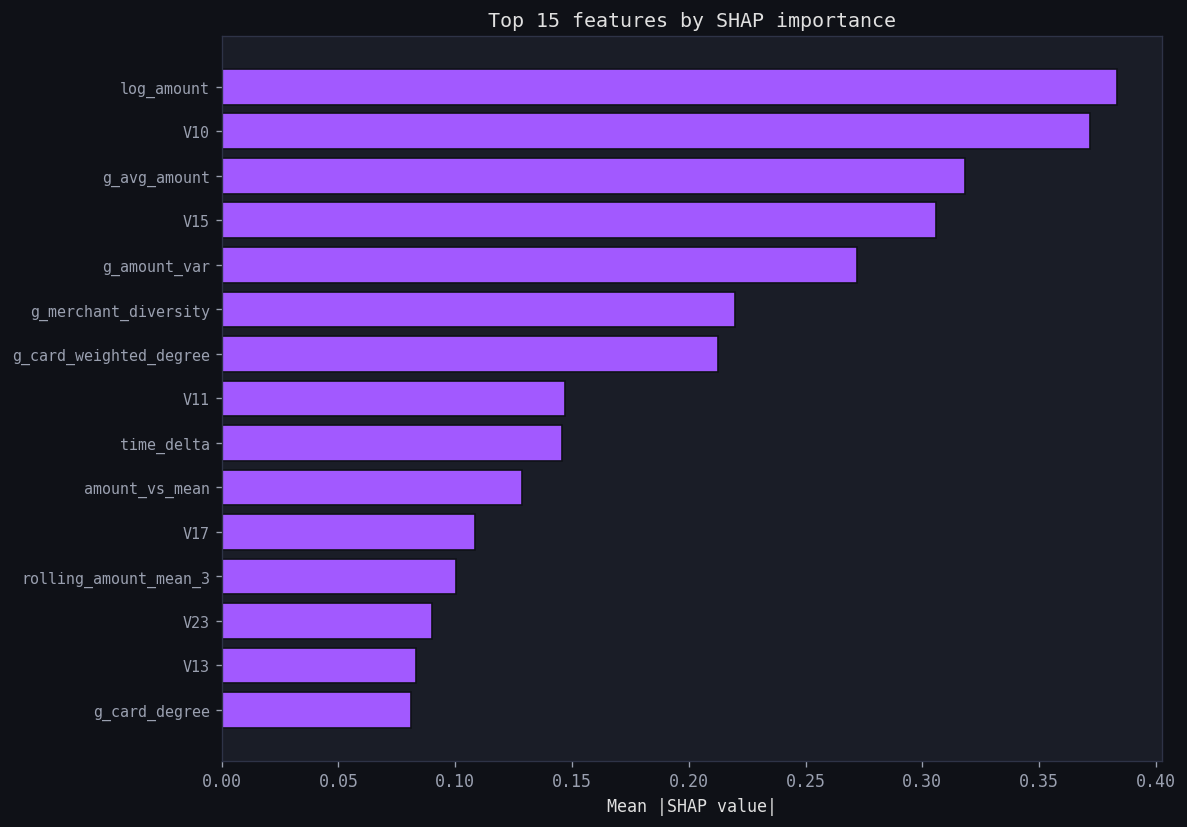

In [10]:
# ── SHAP bar chart ────────────────────────────────────────────────────────────
mean_abs = np.abs(shap_values).mean(0)
order    = np.argsort(mean_abs)[::-1][:15]
names_   = [feature_names[i] for i in order]

fig, ax  = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor("#0F1117"); ax.set_facecolor("#1A1D27")
ax.barh(range(15), mean_abs[order][::-1], color=PAL["purple"], edgecolor="#0F1117")
ax.set_yticks(range(15)); ax.set_yticklabels(names_[::-1], fontsize=9)
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Top 15 features by SHAP importance", color="#E0E0E0", fontsize=12)
plt.tight_layout(); plt.show()
